# Customer Segmentation & Retention Analysis using Online Retail II Dataset

## Project Overview

Customer segmentation is the process of grouping customers based on similar purchasing behavior. Retention analysis focuses on understanding customer loyalty and identifying customers who are at risk of becoming inactive.

In this project, transaction-level data from an online retail company will be analyzed to:

- Understand customer purchasing behavior.
- Segment customers using RFM Analysis and K-Means Clustering.
- Analyze customer retention patterns.
- Generate actionable business recommendations.
- Build an interactive dashboard for business users.

This project follows an end-to-end data science workflow, beginning with raw transaction data and ending with business insights and deployment.

# Business Problem

E-commerce companies collect millions of transaction records every year. However, not all customers contribute equally to business growth.

Some customers purchase frequently and generate high revenue, while others purchase only once and never return.

Without understanding customer behavior, businesses face several challenges:

- Difficulty identifying valuable customers.
- Inefficient marketing campaigns.
- Poor customer retention.
- Low return on marketing investment.

The objective of this project is to analyze historical transaction data to identify meaningful customer segments, evaluate customer retention, and provide recommendations that improve business performance.

# Project Objectives

The primary objectives of this project are:

1. Explore and understand customer transaction data.
2. Clean and preprocess raw retail data.
3. Perform exploratory data analysis (EDA).
4. Engineer customer-level features using RFM Analysis.
5. Segment customers using K-Means Clustering.
6. Analyze customer retention behavior.
7. Generate business recommendations for each customer segment.
8. Develop an interactive dashboard for visualization and decision-making.

# Phase 2: Data Loading

## Objective

The Online Retail II dataset contains transaction records from a UK-based online retailer between December 2009 and December 2011.

For efficient processing, the dataset has been converted into a consolidated CSV file containing the complete transaction history.

The dataset is loaded into a pandas DataFrame, which will be used throughout this project for data cleaning, exploratory analysis, feature engineering, customer segmentation, and retention analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/online_retail_II.csv")

In [3]:
plt.style.use("default")

# Phase 3: Data Understanding

## Objective

Before cleaning or analyzing the data, it is essential to understand its structure, quality, and business context.

The Online Retail II dataset contains transactional records from a UK-based online retailer. Each row represents a product purchased within a customer invoice.

Understanding the available features allows us to identify potential data quality issues and determine which variables are relevant for customer segmentation and retention analysis.

In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.describe(include="all")


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


## Observations

The initial inspection of the dataset reveals several important characteristics:

- The dataset contains **1,067,371 transaction records** across **8 features**.
- Transaction data spans multiple countries, with the United Kingdom appearing most frequently.
- The **Customer ID** column contains a significant number of missing values, which will require careful handling since customer-level analysis depends on this field.
- A small number of missing values are also present in the **Description** column.
- The **InvoiceDate** column is currently stored as a string and will be converted into a datetime format during preprocessing.
- Negative values are observed in both **Quantity** and **Price**, suggesting product returns, cancellations, or erroneous records that must be investigated before analysis.

In [6]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


# Phase 4: Data Cleaning

## Objective

Real-world business datasets often contain missing values, duplicate records, cancelled transactions, invalid entries, and inconsistent data types.

The objective of this phase is to improve the quality of the dataset before performing exploratory analysis and machine learning.

Each cleaning decision will be based on business understanding rather than simply removing data.

## Data Cleaning Strategy

Before modifying the dataset, each data quality issue is investigated individually.

Instead of applying generic cleaning methods, every decision is supported by business reasoning.

The following aspects will be examined:

- Missing values
- Duplicate records
- Data types
- Negative quantities
- Negative prices
- Customer identifiers

Only after understanding the cause of each issue will appropriate cleaning actions be applied.`

In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000


In [10]:
df.duplicated().sum()

np.int64(34335)

## Convert Invoice Date

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [13]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [14]:
df[df["Price"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [15]:
df[df["Customer ID"].isnull()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


## Data Cleaning Decisions

After investigating the dataset, the following cleaning strategy was adopted.

| Data Quality Issue | Decision | Business Justification |
|--------------------|----------|------------------------|
| Missing Product Description | Retained | Product descriptions are not required for customer-level analysis. |
| Missing Customer ID | Removed | Customer segmentation and retention analysis require a unique customer identifier. |
| Duplicate Records | Removed | Duplicate transactions would incorrectly inflate purchase frequency and revenue. |
| Negative Quantity | Removed | Negative quantities represent returned or cancelled orders rather than completed purchases. |
| Negative Price | Removed | Negative prices correspond to accounting adjustments and are not valid customer purchases. |
| InvoiceDate Data Type | Converted to datetime | Required for calculating purchase recency and retention metrics. |

In [16]:
print("Original Shape:", df.shape)

Original Shape: (1067371, 8)


In [17]:
df = df.dropna(subset=["Customer ID"])

In [18]:
df = df.drop_duplicates()

In [19]:
df = df[df["Quantity"] > 0]

In [20]:
df = df[df["Price"] > 0]

In [21]:
df.reset_index(drop=True, inplace=True)

In [22]:
print("Cleaned Shape:", df.shape)

df.head()

Cleaned Shape: (779425, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [23]:
df.shape


(779425, 8)

In [24]:
df.isnull().sum()


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [25]:
df.duplicated().sum()


np.int64(0)

In [26]:
(df["Quantity"] <= 0).sum()


np.int64(0)

In [27]:
(df["Price"] <= 0).sum()

np.int64(0)

# Phase 5: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand customer purchasing behavior, sales patterns, product performance, and geographical distribution.

Rather than generating visualizations without context, each analysis in this section aims to answer a specific business question.

The insights obtained during EDA will guide feature engineering, customer segmentation, and retention analysis in the later stages of the project.

In [28]:
print("Dataset Shape :", df.shape)

print("\nUnique Customers :", df["Customer ID"].nunique())

print("Unique Products :", df["StockCode"].nunique())

print("Unique Invoices :", df["Invoice"].nunique())

print("Countries :", df["Country"].nunique())

Dataset Shape : (779425, 8)

Unique Customers : 5878
Unique Products : 4631
Unique Invoices : 36969
Countries : 41


## Business Question 1

### How large is the cleaned dataset?

Before analyzing customer behavior, it is important to understand the overall scale of the business.

The following statistics summarize the number of:

- Transactions
- Customers
- Products
- Invoices
- Countries

These metrics provide an overview of the retail operation.

In [29]:
country_transactions = (
    df.groupby("Country")["Invoice"]
      .count()
      .sort_values(ascending=False)
      .head(10)
)

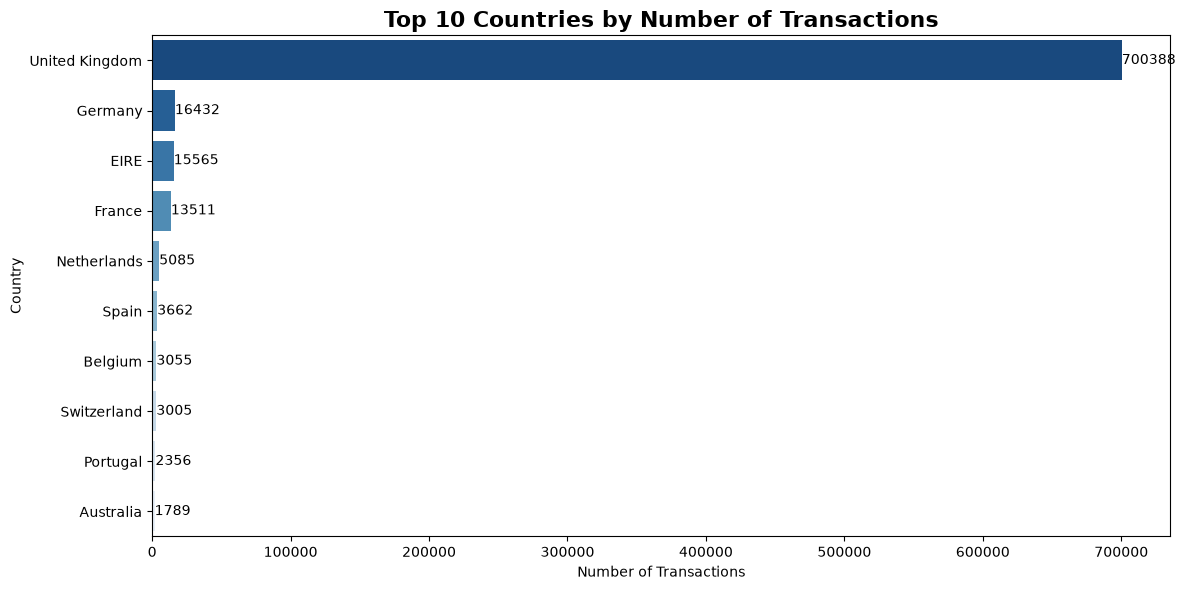

In [30]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=country_transactions.values,
    y=country_transactions.index,
    hue=country_transactions.index,
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Countries by Number of Transactions", fontsize=16, fontweight="bold")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.tight_layout()
plt.show()

In [31]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [32]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

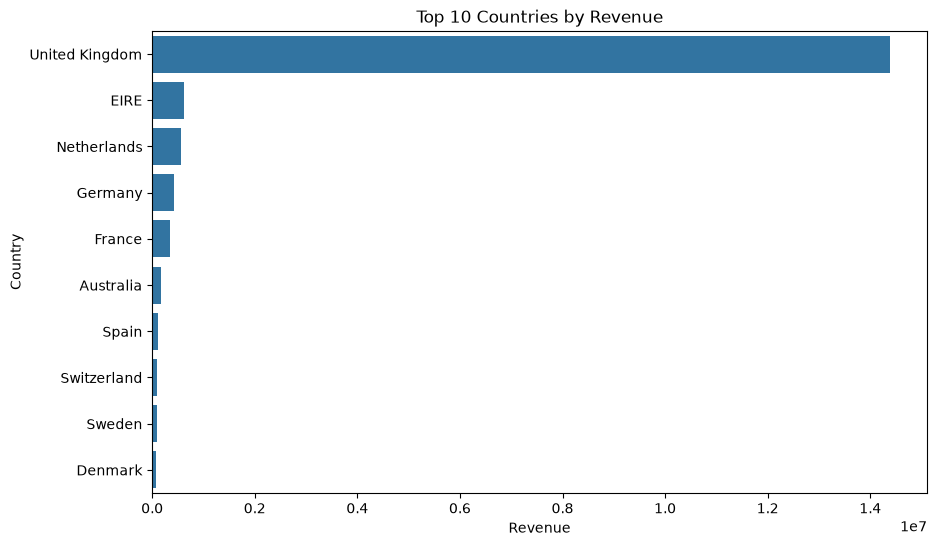

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index
)

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Revenue")

plt.ylabel("Country")

plt.show()

In [34]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

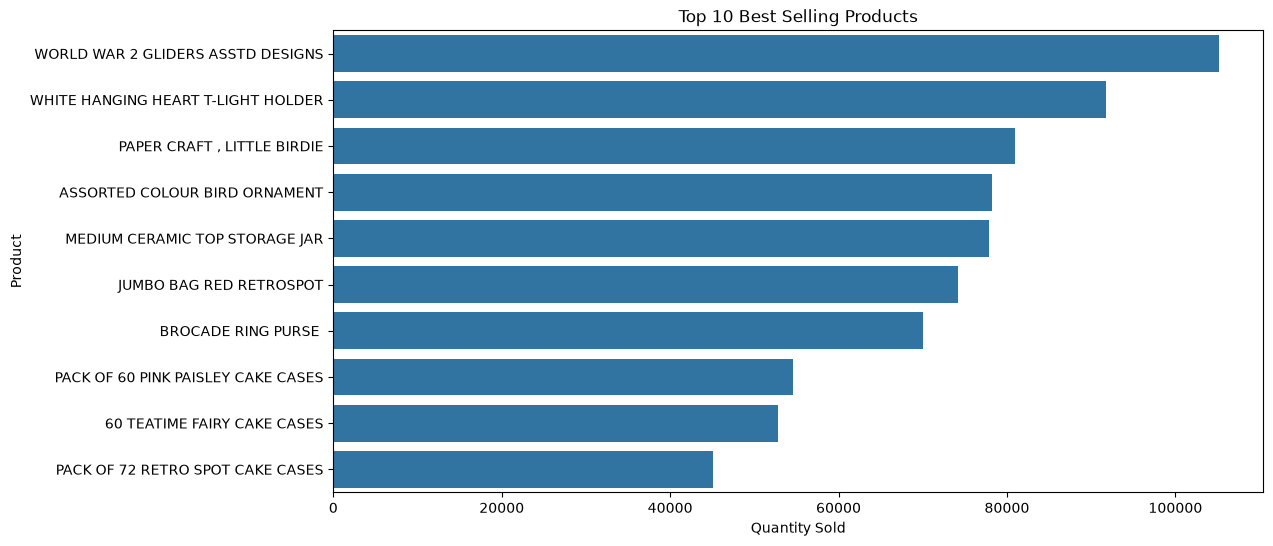

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best Selling Products")

plt.xlabel("Quantity Sold")

plt.ylabel("Product")

plt.show()

### Observation

- The United Kingdom accounts for the overwhelming majority of transactions.
- Germany, France, and EIRE contribute significantly fewer transactions.
- Customer activity is highly concentrated within a single market.

### Business Insight

The business is heavily dependent on the United Kingdom. While international customers are present, expanding customer acquisition and engagement in other countries could reduce geographical concentration risk and increase revenue diversification.

## Business Question 5

### How do sales change over time?

Customer purchasing behavior often varies across different months and seasons.

Analyzing monthly sales trends helps identify seasonal demand, peak shopping periods, and overall business growth.

These insights support inventory planning, marketing campaigns, and sales forecasting.

In [36]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December


In [37]:
monthly_revenue = (
    df.groupby(["Year", "Month"])["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue.head()

,Year,Month,Revenue
0,2009,12,683504.010
1,2010,1,555802.672
2,2010,2,504558.956
3,2010,3,696978.471
4,2010,4,591982.002


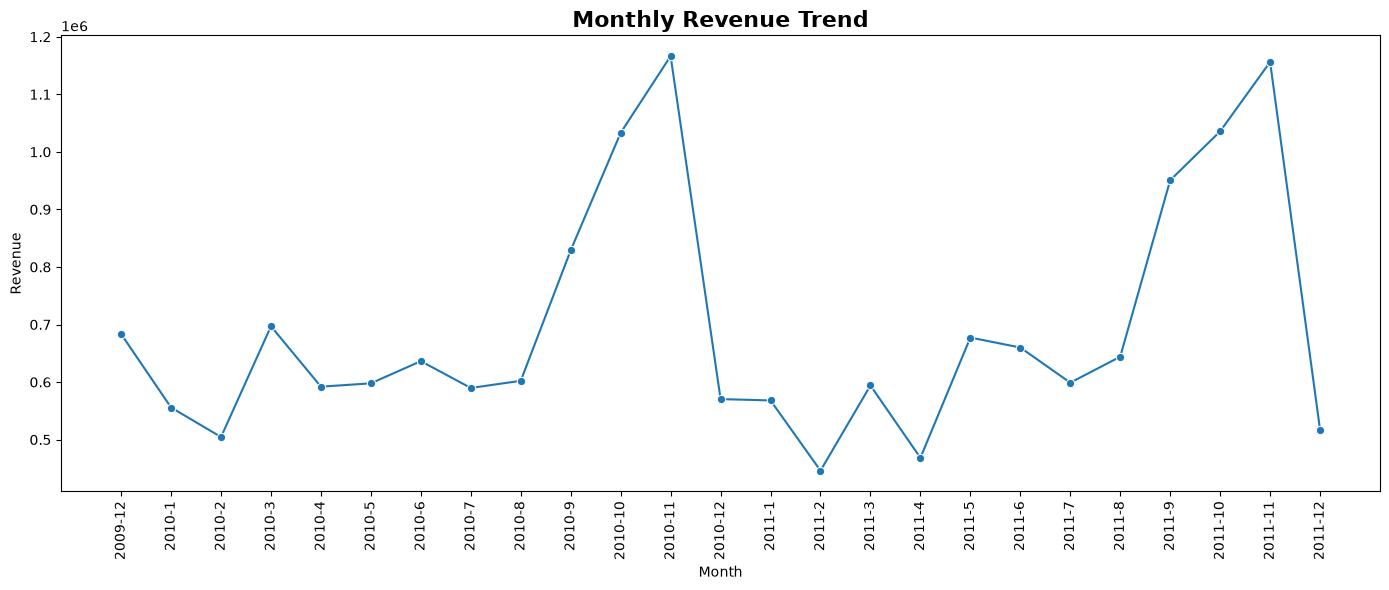

In [38]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_revenue,
    x=range(len(monthly_revenue)),
    y="Revenue",
    marker="o"
)

labels = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"].astype(str)
)

plt.xticks(range(len(labels)), labels, rotation=90)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Business Question 6

### Who are the highest-value customers?

Revenue is not distributed equally among customers.

Identifying the highest revenue-generating customers helps businesses prioritize customer retention strategies and develop personalized marketing campaigns.

In [39]:
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

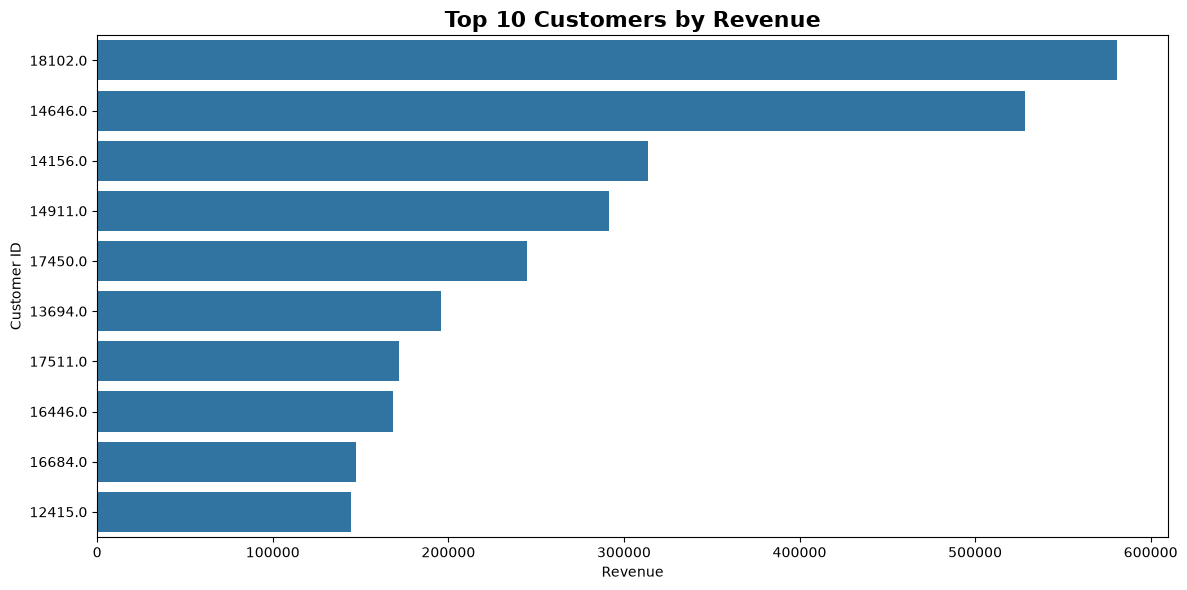

In [40]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=customer_revenue.values,
    y=customer_revenue.index.astype(str)
)

plt.title("Top 10 Customers by Revenue", fontsize=16, fontweight="bold")

plt.xlabel("Revenue")

plt.ylabel("Customer ID")

plt.tight_layout()

plt.show()

## Business Question 7

### Which customers purchase most frequently?

Purchase frequency is an important indicator of customer loyalty.

Customers who place orders frequently are more likely to become long-term customers and contribute consistently to business revenue.

In [41]:
customer_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

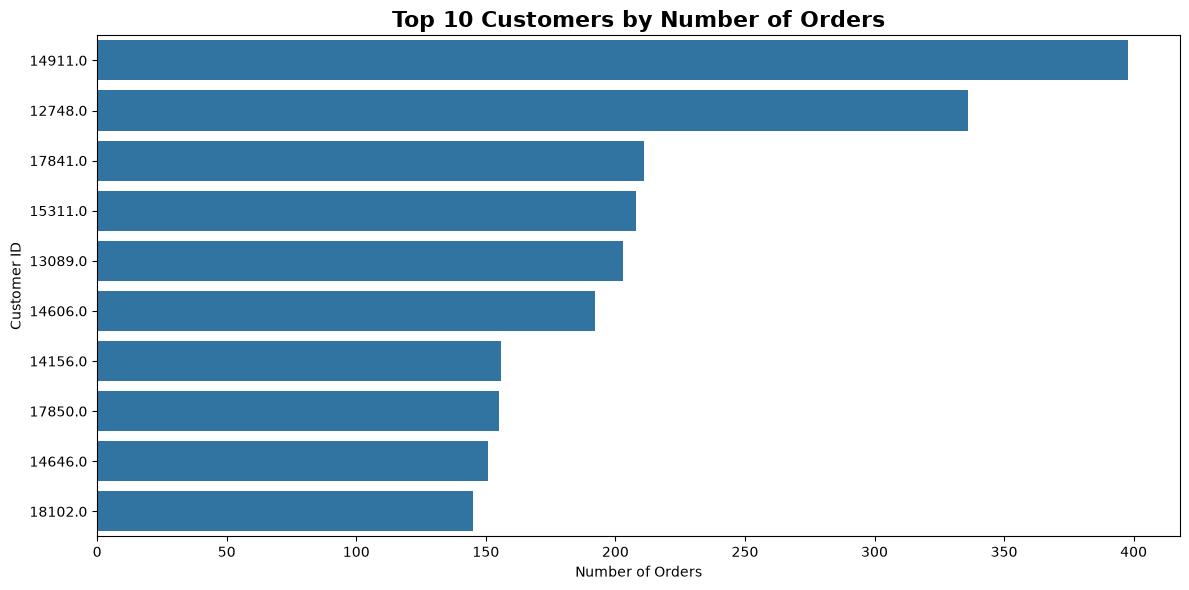

In [42]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=customer_frequency.values,
    y=customer_frequency.index.astype(str)
)

plt.title("Top 10 Customers by Number of Orders", fontsize=16, fontweight="bold")

plt.xlabel("Number of Orders")

plt.ylabel("Customer ID")

plt.tight_layout()

plt.show()

## What is the Average Order Value (AOV)?

### A very important business KPI.

In [43]:
invoice_value = (
    df.groupby("Invoice")["Revenue"]
      .sum()
)

In [44]:
average_order_value = invoice_value.mean()

print(f"Average Order Value : £{average_order_value:.2f}")

Average Order Value : £469.98


# Phase 6: Feature Engineering (RFM Analysis)

## Objective

Customer segmentation based solely on raw transaction data is difficult because each customer may have multiple purchases over time.

To summarize customer purchasing behavior, RFM Analysis is performed.

RFM stands for:

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Number of unique purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These three metrics provide a concise representation of customer value and form the foundation for customer segmentation and retention analysis.

In [45]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

analysis_date

C:\Users\HP\AppData\Local\Temp\ipykernel_32236\1466368544.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)


Timestamp('2011-12-10 12:50:00')

In [46]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("Customer ID")
      .agg({
          "InvoiceDate": lambda x: (analysis_date - x.max()).days,
          "Invoice": "nunique",
          "Revenue": "sum"
      })
)

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

rfm.shape

C:\Users\HP\AppData\Local\Temp\ipykernel_32236\2907097823.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)


(5878, 3)

# Phase 6.2: Exploring RFM Features

## Objective

Before applying K-Means clustering, the RFM features must be analyzed to understand their distribution and identify potential outliers.

Since K-Means is a distance-based algorithm, features with different scales or extreme values can significantly influence the clustering results.

This analysis helps determine whether transformations or feature scaling are required before model training.

In [47]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


In [48]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

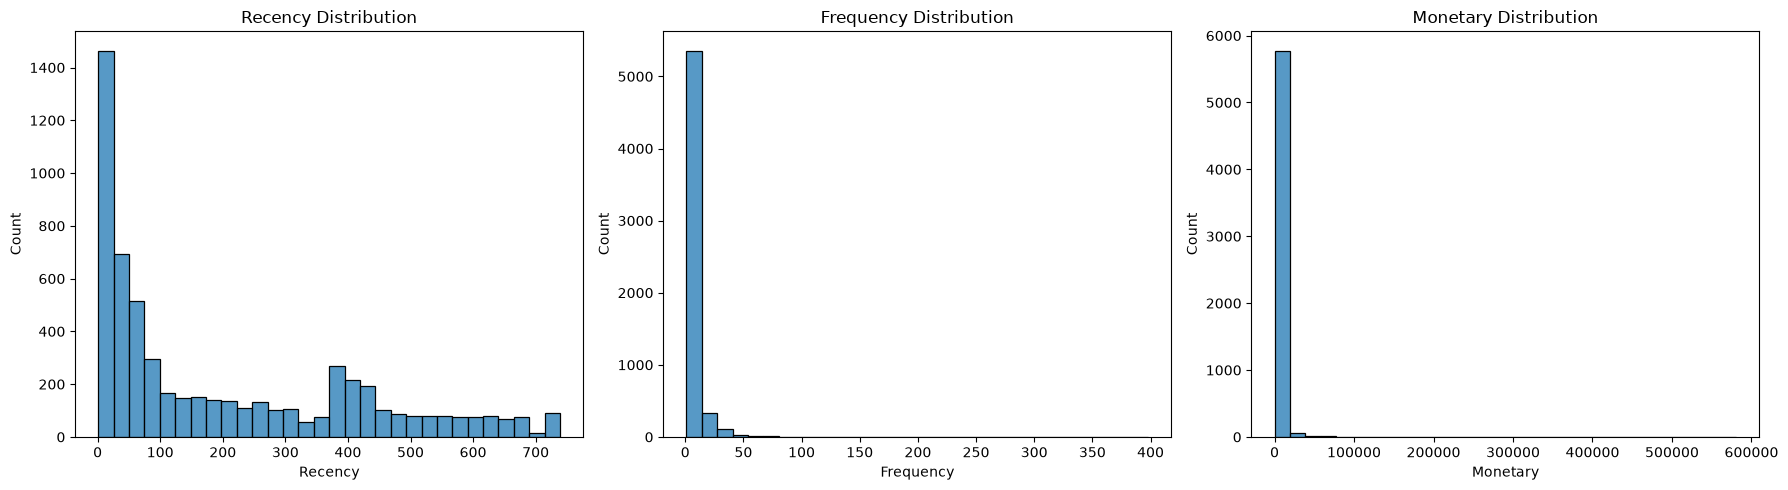

In [49]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(rfm["Recency"], ax=axes[0], bins=30)
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], ax=axes[1], bins=30)
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], ax=axes[2], bins=30)
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

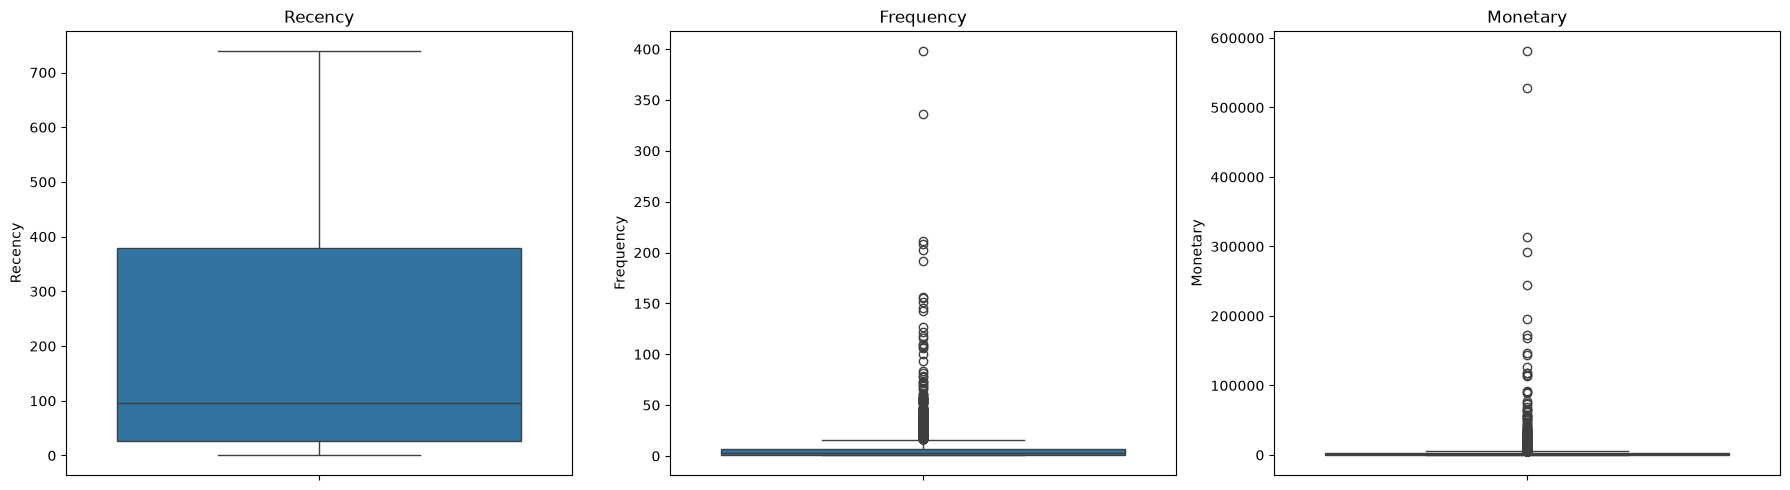

In [50]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(y=rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency")

sns.boxplot(y=rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")

sns.boxplot(y=rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

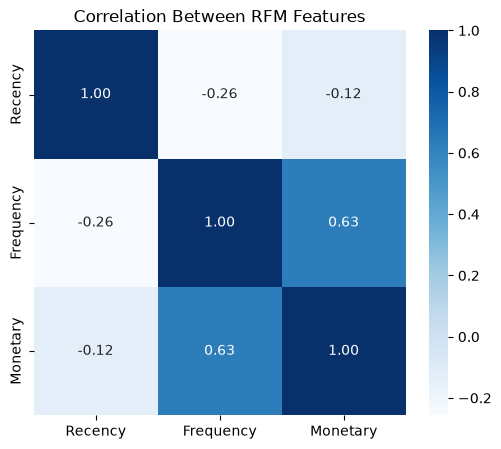

In [51]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between RFM Features")

plt.show()

## Business Questions

Before clustering, we investigate the following:

- Are customers generally recent or inactive?
- Do most customers purchase frequently or only occasionally?
- Is customer spending evenly distributed or dominated by a small group of high-value customers?
- Are there extreme outliers that could affect clustering?
- How strongly are the RFM features related to one another?

The answers will determine the preprocessing steps required before applying K-Means.

# Phase 6.3: Data Transformation

## Objective

The RFM features exhibit highly skewed distributions and contain extreme values, particularly for Frequency and Monetary.

Since K-Means clustering relies on Euclidean distance, features with large scales can dominate the clustering process.

To improve clustering quality:

- A logarithmic transformation is applied to reduce skewness.
- Standardization is performed to ensure all features contribute equally during clustering.

In [52]:
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

rfm_log.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,5.789960,2.564949,11.258774
12347.0,1.098612,2.197225,8.501578
12348.0,4.330733,1.791759,7.611051
12349.0,2.995732,1.609438,8.396085
12350.0,5.739793,0.693147,5.815324


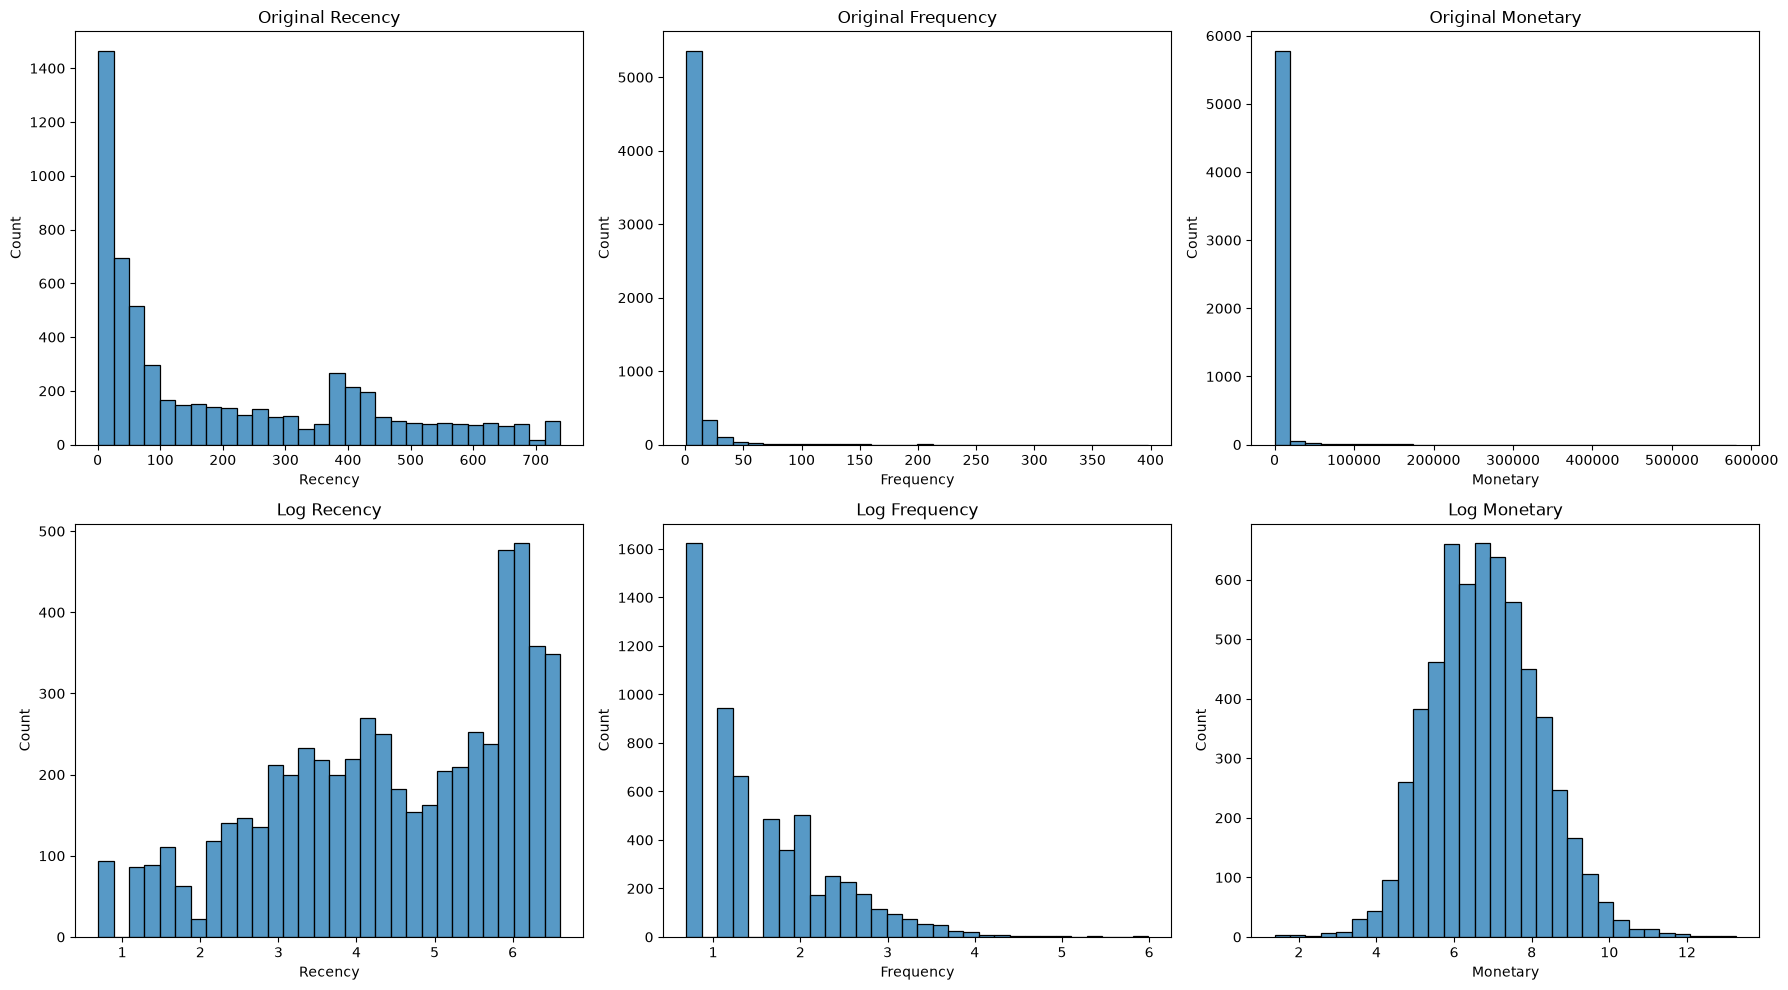

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Original
sns.histplot(rfm["Recency"], bins=30, ax=axes[0,0])
axes[0,0].set_title("Original Recency")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[0,1])
axes[0,1].set_title("Original Frequency")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[0,2])
axes[0,2].set_title("Original Monetary")

# Log transformed
sns.histplot(rfm_log["Recency"], bins=30, ax=axes[1,0])
axes[1,0].set_title("Log Recency")

sns.histplot(rfm_log["Frequency"], bins=30, ax=axes[1,1])
axes[1,1].set_title("Log Frequency")

sns.histplot(rfm_log["Monetary"], bins=30, ax=axes[1,2])
axes[1,2].set_title("Log Monetary")

plt.tight_layout()
plt.show()

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [55]:
rfm_scaled[:5]

array([[ 0.85670058,  1.25449595,  3.20621937],
       [-2.15197903,  0.80016603,  1.21599349],
       [-0.07913835,  0.29920733,  0.57318471],
       [-0.93530818,  0.07394609,  1.13984551],
       [ 0.82452706, -1.05814595, -0.72302406]])

# Phase 7: Customer Segmentation using K-Means

## Objective

The objective of this phase is to group customers with similar purchasing behavior based on their RFM characteristics.

Since K-Means requires the number of clusters as an input, two evaluation techniques are used:

- **Elbow Method:** Measures the Within-Cluster Sum of Squares (WCSS) to identify the point where adding more clusters provides diminishing returns.
- **Silhouette Score:** Measures how well-separated the resulting clusters are. Higher values indicate better-defined clusters.

Using both methods helps select an appropriate number of customer segments before training the final model.

In [56]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    wcss.append(model.inertia_)

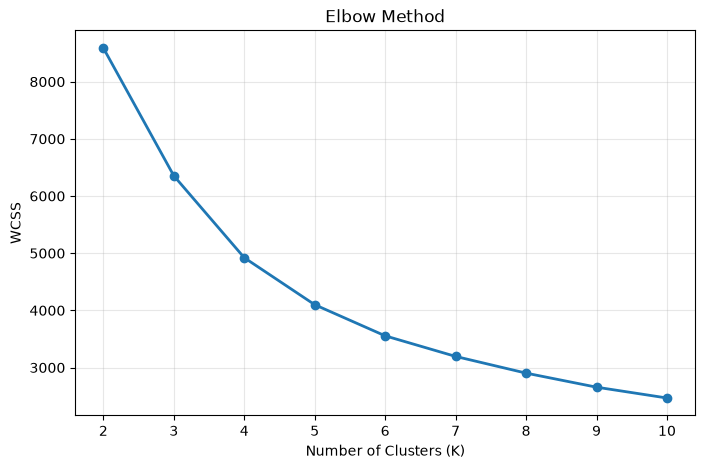

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.show()

In [58]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    scores.append(score)

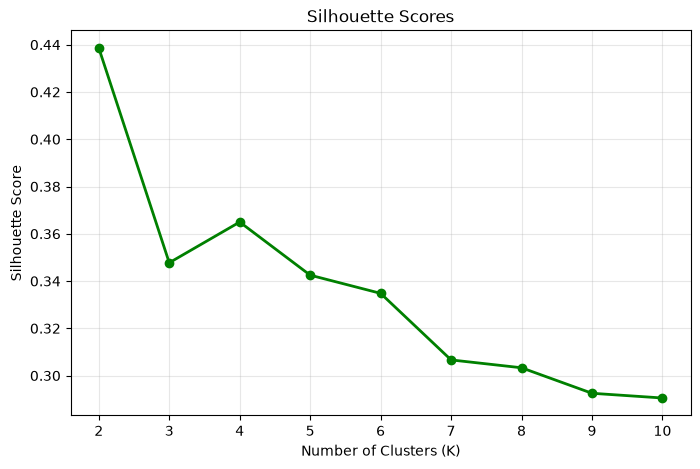

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Silhouette Scores")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.grid(alpha=0.3)

plt.show()

In [60]:
for k, score in zip(range(2,11), scores):
    print(f"K={k}  -->  {score:.4f}")

K=2  -->  0.4386
K=3  -->  0.3477
K=4  -->  0.3650
K=5  -->  0.3425
K=6  -->  0.3348
K=7  -->  0.3066
K=8  -->  0.3033
K=9  -->  0.2925
K=10  -->  0.2905


## Choosing the Optimal Number of Clusters

The optimal number of clusters was determined using both the Elbow Method and the Silhouette Score.

### Elbow Method
The WCSS curve shows a noticeable bend around **K = 4**, indicating that additional clusters provide only marginal improvements.

### Silhouette Score
Although the highest Silhouette Score is obtained for **K = 2**, this solution creates only two broad customer groups, limiting its business usefulness.

The Silhouette Score for **K = 4** remains relatively high while providing more meaningful customer segmentation.

### Final Decision

Based on both quantitative evaluation and business interpretability, **4 clusters** were selected for the final K-Means model.

In [61]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [62]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,2
12347.0,2,8,4921.53,2
12348.0,75,5,2019.40,3
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,0


In [63]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64

In [64]:
cluster_profile = (
    rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]]
       .mean()
       .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,394.95,1.38,317.08
1,28.30,3.05,857.49
2,27.71,19.28,10731.16
3,230.07,5.06,1948.50


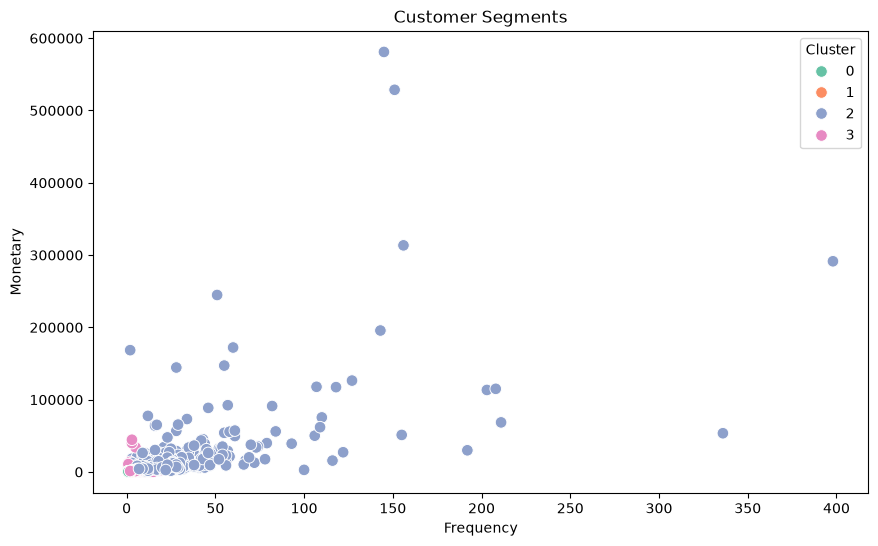

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Customer Segments")
plt.show()

### The  above graph dint work coz of outliers

In [66]:
cluster_profile = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
       .agg(["mean", "median", "count"])
       .round(2)
)

cluster_profile

Recency              Frequency               Monetary               
           mean median count      mean median count      mean   median count
Cluster                                                                     
0        394.95  402.0  1973      1.38    1.0  1973    317.08   273.31  1973
1         28.30   24.0  1250      3.05    3.0  1250    857.49   734.12  1250
2         27.71   17.0  1196     19.28   13.0  1196  10731.16  4986.12  1196
3        230.07  186.0  1459      5.06    4.0  1459   1948.50  1450.04  1459

# Phase 7.3: Customer Segment Interpretation

## Cluster 0 – Lost Customers

- High Recency
- Very Low Frequency
- Very Low Monetary Value

These customers have not purchased for a long period and contribute minimal revenue. They are likely inactive and suitable for targeted re-engagement campaigns.

---

## Cluster 1 – Regular Customers

- Low Recency
- Moderate Frequency
- Moderate Spending

These customers are active and contribute consistently to business revenue. Loyalty programs and personalized recommendations can encourage more frequent purchases.

---

## Cluster 2 – VIP Customers

- Low Recency
- Highest Frequency
- Highest Monetary Value

These customers represent the most valuable customer segment. They should be prioritized through premium services, exclusive offers, and retention initiatives.

---

## Cluster 3 – At-Risk Customers

- Moderate to High Recency
- Moderate Frequency
- Good Monetary Value

These customers were previously engaged but have not purchased recently. Personalized retention campaigns can help reactivate them before they become inactive.

#### Q1) How many customers belong to each segment?

In [67]:
segment_map = {
    0: "Lost Customers",
    1: "Regular Customers",
    2: "VIP Customers",
    3: "At-Risk Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,12,77556.46,2,VIP Customers
12347.0,2,8,4921.53,2,VIP Customers
12348.0,75,5,2019.40,3,At-Risk Customers
12349.0,19,4,4428.69,1,Regular Customers
12350.0,310,1,334.40,0,Lost Customers


In [68]:
segment_count = rfm["Segment"].value_counts()

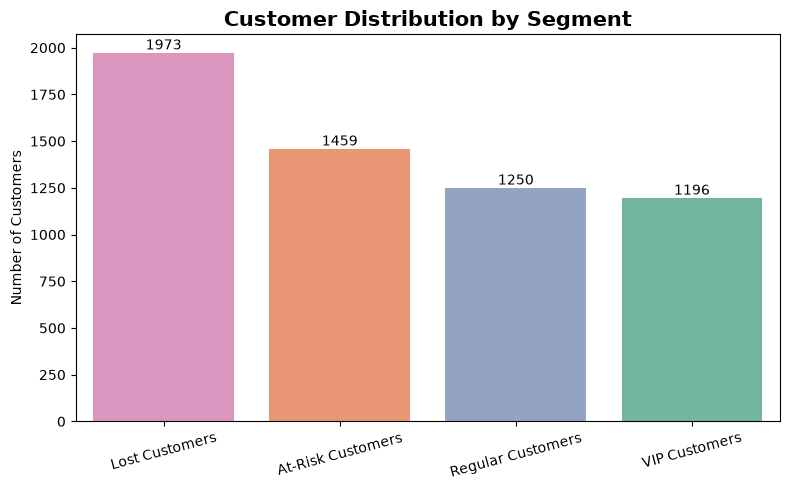

In [69]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=rfm,
    x="Segment",
    order=segment_count.index,
    hue="Segment",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Segment", fontsize=15, fontweight="bold")
plt.xlabel("")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

#### Q2) Which segment generates the most revenue?

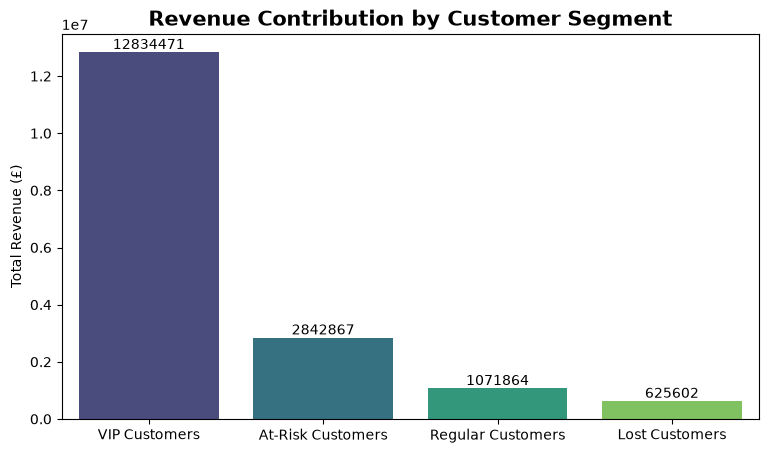

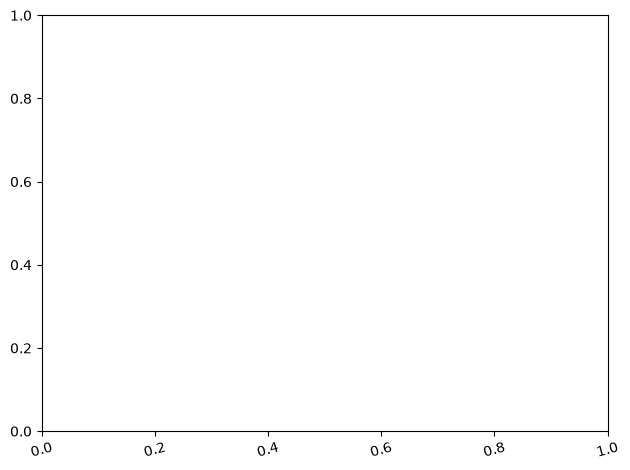

In [70]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
       .sum()
       .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values,
    hue=segment_revenue.index,
    palette="viridis",
    legend=False
)

plt.title("Revenue Contribution by Customer Segment",
          fontsize=15,
          fontweight="bold")

plt.xlabel("")
plt.ylabel("Total Revenue (£)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

plt.xticks(rotation=15)

plt.tight_layout()

#### Q3) What percentage of customers belong to each segment?

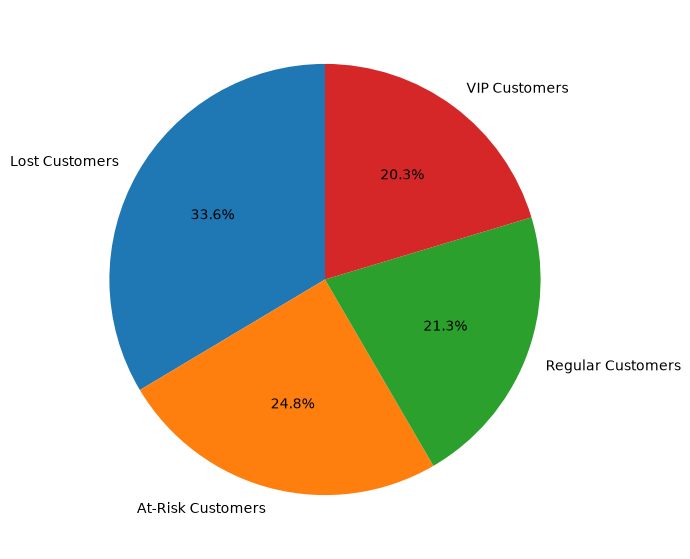

Text(0.5, 1.0, 'Customer Segment Distribution')

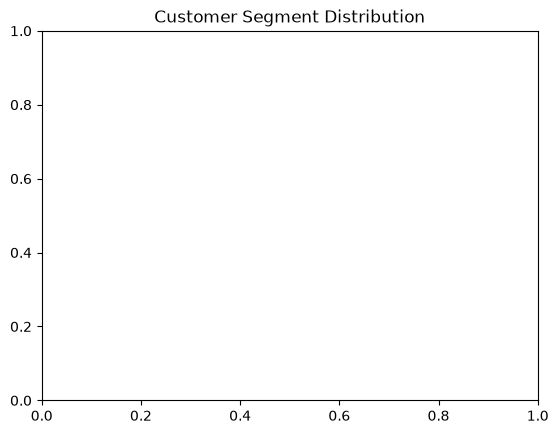

In [71]:
segment_percent = (
    rfm["Segment"].value_counts(normalize=True) * 100
)

plt.figure(figsize=(7,7))

plt.pie(
    segment_percent.values,
    labels=segment_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.show()

plt.title("Customer Segment Distribution")

#### Executive Summary

In [72]:
segment_summary = (
    rfm.groupby("Segment")
       .agg({
           "Recency":"mean",
           "Frequency":"mean",
           "Monetary":["mean","sum","count"]
       })
       .round(2)
)

segment_summary

Recency Frequency  Monetary                   
                     mean      mean      mean          sum count
Segment                                                         
At-Risk Customers  230.07      5.06   1948.50   2842867.24  1459
Lost Customers     394.95      1.38    317.08    625601.80  1973
Regular Customers   28.30      3.05    857.49   1071864.29  1250
VIP Customers       27.71     19.28  10731.16  12834470.94  1196

# Phase 8: Retention Analysis

## Executive Summary

The customer base was successfully segmented into four groups based on Recency, Frequency, and Monetary (RFM) characteristics.

### Key Findings

- Lost Customers represent the largest customer segment.
- VIP Customers generate the highest revenue despite being a smaller proportion of the customer base.
- At-Risk Customers present an important opportunity for retention campaigns.
- Regular Customers contribute stable revenue and should be nurtured through loyalty initiatives.

The segmentation enables the business to allocate marketing resources more effectively and personalize customer engagement strategies.

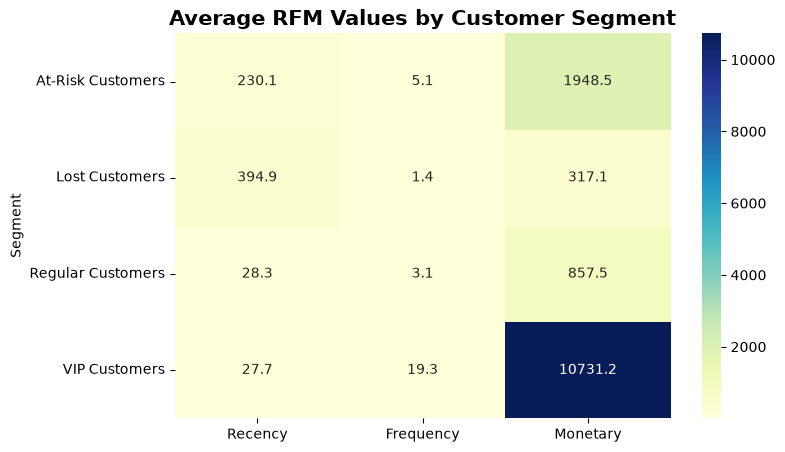

In [73]:
cluster_profile = (
    rfm.groupby("Segment")[["Recency","Frequency","Monetary"]]
       .mean()
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Average RFM Values by Customer Segment",
          fontsize=15,
          fontweight="bold")

plt.show()

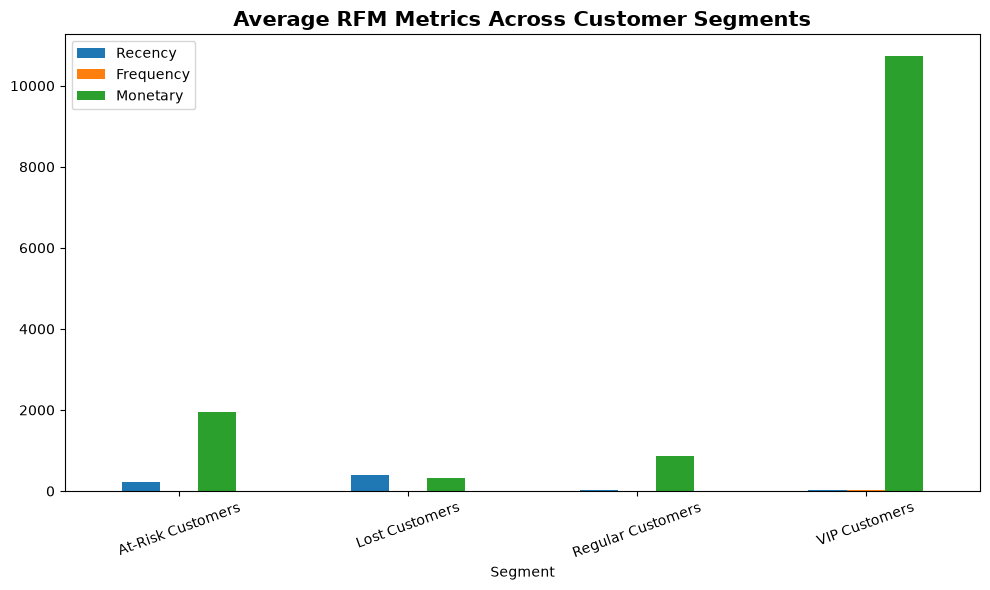

In [74]:
cluster_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average RFM Metrics Across Customer Segments",
          fontsize=15,
          fontweight="bold")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# Business Recommendations

Based on the customer segmentation analysis, the following business strategies are recommended.

| Customer Segment | Business Strategy |
|------------------|-------------------|
| VIP Customers | Reward loyalty through exclusive memberships, premium support, and early access to new products. |
| Regular Customers | Encourage repeat purchases using loyalty programs and personalized product recommendations. |
| At-Risk Customers | Launch targeted retention campaigns, reminder emails, and limited-time offers. |
| Lost Customers | Implement win-back campaigns with promotional discounts or reactivation offers. |

These strategies enable businesses to optimize marketing resources by targeting customers according to their purchasing behavior.

In [75]:
import joblib

joblib.dump(kmeans, "../models/kmeans_model.pkl")

['../models/kmeans_model.pkl']

In [76]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [77]:
rfm = rfm.reset_index()          # Customer ID becomes a column
rfm = rfm.rename(columns={
    "Customer ID": "CustomerID"
})

print(rfm.columns)               # Verify
rfm.to_csv("../data/customer_segments.csv", index=False)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment'], dtype='object')


In [79]:
check = pd.read_csv("../data/customer_segments.csv")
print(check.columns)
print(check.head())

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment'], dtype='object')
   CustomerID  Recency  Frequency  Monetary  Cluster            Segment
0     12346.0      326         12  77556.46        2      VIP Customers
1     12347.0        2          8   4921.53        2      VIP Customers
2     12348.0       75          5   2019.40        3  At-Risk Customers
3     12349.0       19          4   4428.69        1  Regular Customers
4     12350.0      310          1    334.40        0     Lost Customers


In [80]:
from pathlib import Path

print(Path("../data/customer_segments.csv").resolve())

C:\Users\HP\Desktop\Customer\data\customer_segments.csv


In [78]:
loaded_model = joblib.load("../models/kmeans_model.pkl")

loaded_scaler = joblib.load("../models/scaler.pkl")